In [1]:
import h5py as h5
import numpy as np
import os
import torch
import matplotlib.pyplot as plt
from tqdm import tqdm
data_path = '/home3/rfit/Telescope_Array/phd_work/data/normed/pr_photon_0001_excl_sat_T_excl_geo_T.h5'

In [2]:
'''
mc_params (num_evs,10):
0. mc_event_num
1. mc_parttype (CORSIKA, 1 - gamma, 14 - proton, 5626 - Fe)
2. mc_corecounter, closest to core detector number
3. mc_E (for primaries other than photon energy is rescaled by 1/1.27, i.e. to proton FD energy scale)
4. mc_theta
5. mc_phi
6. mc_height_1st_inter, km
7. mc_xcore
8. mc_ycore
9. mc_border_distance, km 
'''
with h5.File(data_path,'r') as f:
    print('keys', list(f.keys()))
    test = f['test']
    keys = list(test.keys())
    test_mc_params = test['mc_params'][:]
    for k in keys:
        print(k, test[k].shape)
        ev_ids = test["ev_ids"][:]

    ev_starts_test = test['ev_starts'][:]
    train = f['train']
    ev_starts_train = train['ev_starts'][:]
    keys = list(test.keys())
    train_mc_params = train['mc_params'][:]
    for k in keys:
        print(k, train[k].shape)
        train_ev_ids = train["ev_ids"][:]

keys ['norm_param', 'test', 'train', 'val']
dt_mask (1143461, 2)
dt_params (22472816, 6)
ev_ids (1143461, 3)
ev_starts (1143462,)
mc_params (1143461, 10)
recos (1143461, 6)
dt_mask (10291149, 2)
dt_params (202245823, 6)
ev_ids (10291149, 3)
ev_starts (10291150,)
mc_params (10291149, 10)
recos (10291149, 6)


mc_params (num_evs,10):
0. mc_event_num
1. mc_parttype (CORSIKA, 1 - gamma, 14 - proton, 5626 - Fe)
2. mc_corecounter, closest to core detector number
3. mc_E (for primaries other than photon energy is rescaled by 1/1.27, i.e. to proton FD energy scale)
4. mc_theta
5. mc_phi
6. mc_height_1st_inter, km
7. mc_xcore
8. mc_ycore
9. mc_border_distance, km 

Uniq chanels 
Утверждено 23,12,2025

- theta(4)
- particle (1)
- mc_height_1st_inter (6)

In [3]:
(np.diff(ev_starts_train)==6).sum()

147770

In [4]:
ph_mask = train_mc_params[:,1]==1
ph_mask_test = test_mc_params[:,1]==1

In [5]:
np.diff(ev_starts_train).shape, ph_mask.shape

((10291149,), (10291149,))

In [6]:
for i in range(20):
    num = (np.diff(ev_starts_train)[ph_mask]==i).sum() + (np.diff(ev_starts_test)[ph_mask_test]==i).sum()
    print(i, num)

0 0
1 0
2 0
3 2
4 97
5 3730
6 77757
7 211421
8 290104
9 303988
10 280283
11 248513
12 223226
13 206461
14 195124
15 185875
16 177056
17 166267
18 153428
19 138364


In [7]:
chois_param_index = [1, 4]
chois_mc_params = mc_params[:, chois_param_index]
unique_mc_params = np.unique(chois_mc_params, axis=0)
unique_mc_params.shape[0], mc_params.shape[0], unique_mc_params.shape[0]/mc_params.shape[0]

NameError: name 'mc_params' is not defined

In [4]:
chois_param_index = [1, 6]
chois_mc_params = mc_params[:, chois_param_index]
unique_mc_params = np.unique(chois_mc_params, axis=0)
unique_mc_params.shape[0], mc_params.shape[0], unique_mc_params.shape[0]/mc_params.shape[0]

(7231, 1143461, 0.00632378367080294)

In [5]:
chois_param_index = [1, 6, 4]
chois_mc_params = mc_params[:, chois_param_index]
unique_mc_params = np.unique(chois_mc_params, axis=0)
unique_mc_params.shape[0], mc_params.shape[0], unique_mc_params.shape[0]/mc_params.shape[0]

(8222, 1143461, 0.0071904507455873)

In [6]:
unique_params, inverse_indices = np.unique(chois_mc_params, axis=0, return_inverse=True)
# Создаем список массивов индексов для каждой группы
group_indices = []
for i in tqdm(range(len(unique_params))):
    group_indices.append(np.where(inverse_indices == i)[0])

100%|██████████| 8222/8222 [00:05<00:00, 1371.23it/s]


# Чтение из прогона

In [2]:
path = "/home/rfit/Telescope_Array/phd_work/src/train_VAE/runs_tests"

proton_path = os.path.join(path, 'pr')
photon_path = os.path.join(path, 'photon')

In [3]:
embeding_name = 'embading.npy'
preds_log_var_name = 'preds_log_var.npy'
num_det_name = 'num_det.npy'
recon_loss_name = 'recon_loss.npy'
loss_num_det_name = 'loss_num_det.npy'
num_det_pred_name = 'preds_num_det.npy'


embeding = np.load(os.path.join(proton_path, embeding_name), allow_pickle=True)
num_det = np.load(os.path.join(proton_path, num_det_name), allow_pickle=True)
recon_loss = np.load(os.path.join(proton_path, recon_loss_name), allow_pickle=True)

print(embeding.shape, num_det.shape, recon_loss.shape)

(779042, 16) (779042,) (779042,)


In [4]:
embeding_pr = np.load(os.path.join(proton_path, embeding_name), allow_pickle=True)
preds_log_var_pr = np.load(os.path.join(proton_path, preds_log_var_name), allow_pickle=True)
num_det_pr = np.load(os.path.join(proton_path, num_det_name), allow_pickle=True)
recon_loss_pr = np.load(os.path.join(proton_path, recon_loss_name), allow_pickle=True)
loss_num_det_pr = np.load(os.path.join(proton_path, loss_num_det_name), allow_pickle=True)
num_det_pred_pr = np.load(os.path.join(proton_path, num_det_pred_name), allow_pickle=True)[:,0]

embeding_ph = np.load(os.path.join(photon_path, embeding_name), allow_pickle=True)
preds_log_var_ph = np.load(os.path.join(photon_path, preds_log_var_name), allow_pickle=True)
num_det_ph = np.load(os.path.join(photon_path, num_det_name), allow_pickle=True)
recon_loss_ph = np.load(os.path.join(photon_path, recon_loss_name), allow_pickle=True)
loss_num_det_ph = np.load(os.path.join(photon_path, loss_num_det_name), allow_pickle=True)
num_det_pred_ph = np.load(os.path.join(photon_path, num_det_pred_name), allow_pickle=True)[:,0]

recon_loss_ph.shape

(364419,)

In [5]:
num_det_pred_pr.shape

(779042,)

(779042,) (779042,)
(364419,) (364419,)


/tmp/ipykernel_10637/813526106.py:136: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box1 = ax.boxplot(grouped_data1, positions=positions1, widths=0.35,
/tmp/ipykernel_10637/813526106.py:139: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box2 = ax.boxplot(grouped_data2, positions=positions2, widths=0.35,


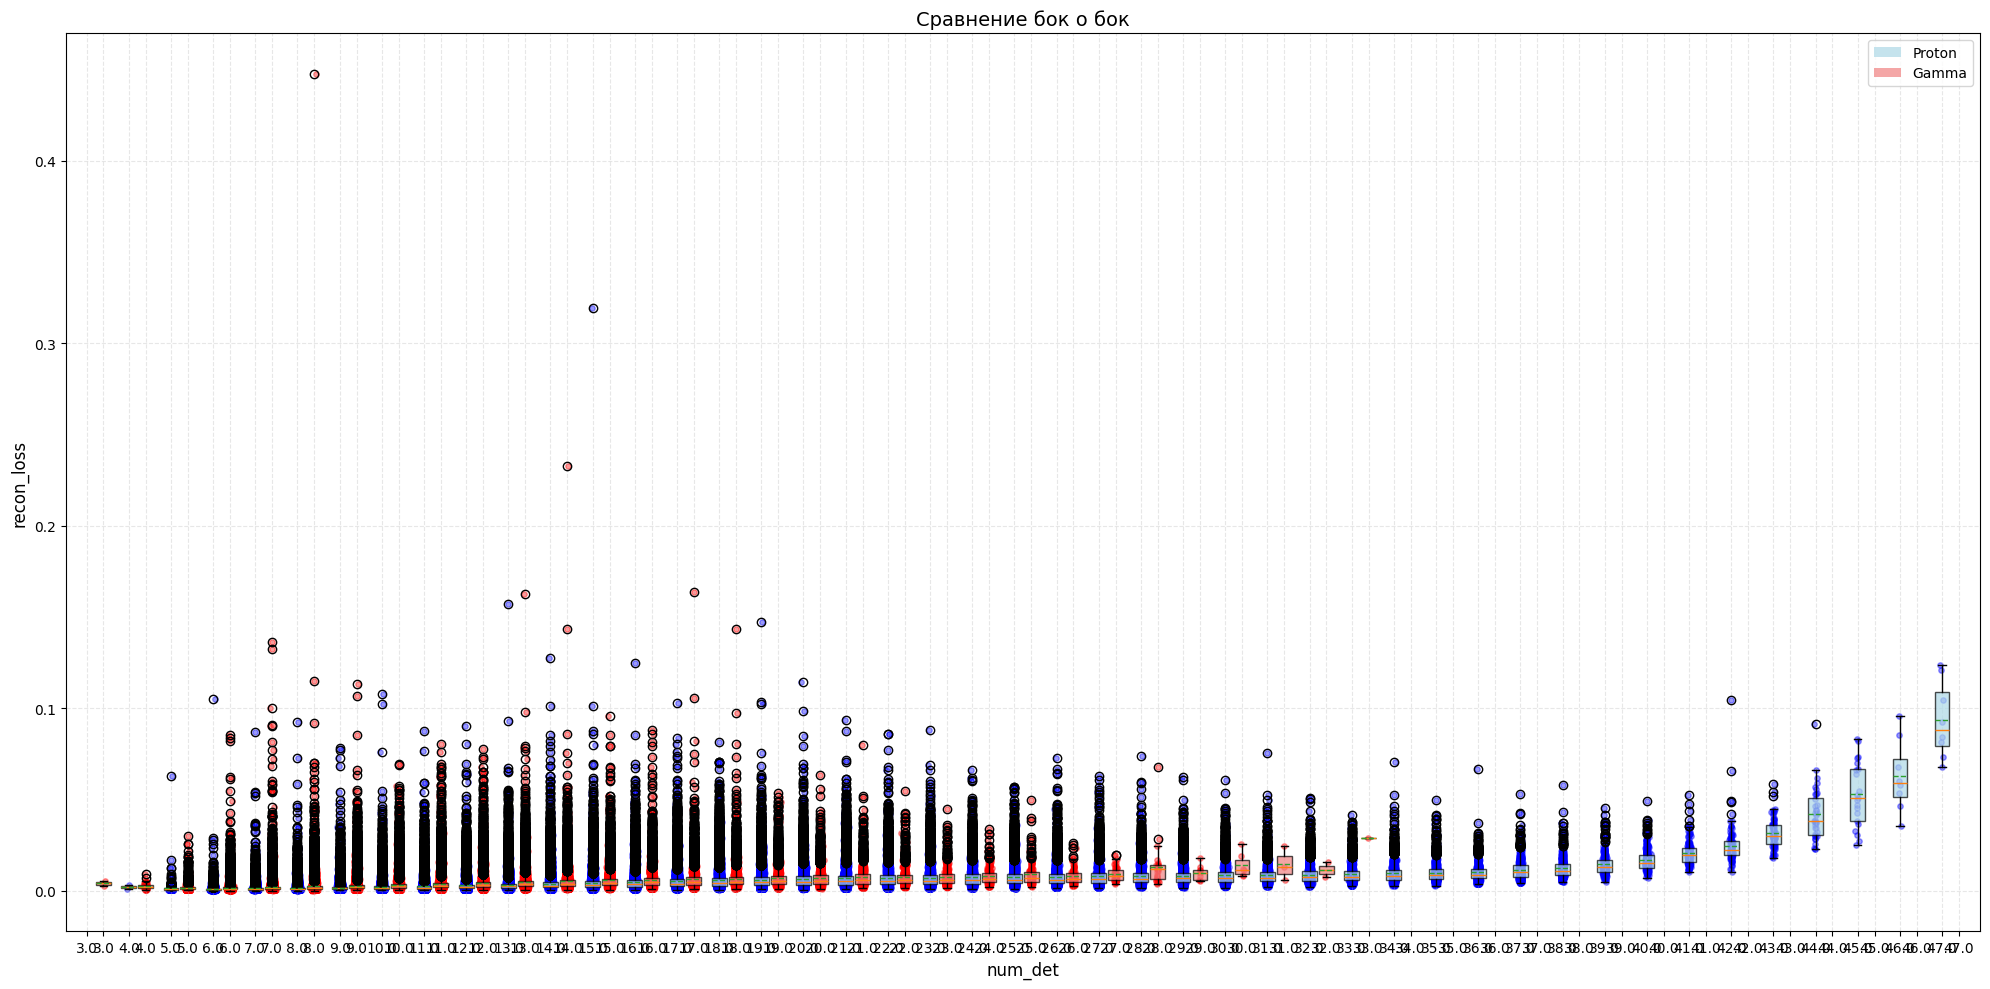

In [6]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from typing import Optional, Tuple, List, Dict, Union

def plot_boxplot_comparison(
    data1: Union[pd.DataFrame, Tuple[List, List], Dict[str, List]],
    data2: Optional[Union[pd.DataFrame, Tuple[List, List], Dict[str, List]]] = None,
    labels1: Optional[str] = "Набор 1",
    labels2: Optional[str] = "Набор 2",
    title: str = "Сравнение распределений recon_loss по num_det",
    figsize: Tuple[int, int] = (12, 8),
    show_points: bool = False,
    show_means: bool = True,
    share_x: bool = True,
    style: str = "single"  # 'single', 'side_by_side', 'overlay'
):   
    def prepare_data(data):
        """Преобразует данные в DataFrame"""
        if isinstance(data, pd.DataFrame):
            df = data.copy()
        elif isinstance(data, tuple) and len(data) == 2:
            df = pd.DataFrame({
                'num_det': data[0],
                'recon_loss': data[1]
            })
        elif isinstance(data, dict):
            df = pd.DataFrame(data)
        else:
            raise ValueError("Неправильный формат данных")
        
        # Убедимся, что колонки есть
        if 'num_det' not in df.columns or 'recon_loss' not in df.columns:
            raise ValueError("Данные должны содержать 'num_det' и 'recon_loss'")
        
        return df.sort_values('num_det')
    
    # Подготавливаем данные
    df1 = prepare_data(data1)
    df2 = prepare_data(data2) if data2 is not None else None
    
    if data2 is None:
        # Рисуем только один набор данных
        fig, ax = plt.subplots(figsize=figsize)
        
        # Группируем данные
        grouped_data = [group['recon_loss'].values 
                       for _, group in df1.groupby('num_det')]
        labels = sorted(df1['num_det'].unique())
        
        # Создаем бокс-плот
        box = ax.boxplot(
            grouped_data, 
            labels=labels,
            patch_artist=True,
            showmeans=show_means,
            meanline=show_means
        )
        
        # Настройка цвета
        for patch in box['boxes']:
            patch.set_facecolor('lightblue')
            patch.set_alpha(0.7)
        
        # Добавляем точки, если нужно
        if show_points:
            for i, data in enumerate(grouped_data, 1):
                x = np.random.normal(i, 0.04, size=len(data))
                ax.scatter(x, data, alpha=0.4, s=20, color='blue')
        
        ax.set_xlabel('num_det', fontsize=12)
        ax.set_ylabel('recon_loss', fontsize=12)
        ax.set_title(f'{title} ({labels1})', fontsize=14)
        ax.grid(True, alpha=0.3, linestyle='--')
        
    else:
        # Сравниваем два набора данных
        if style == 'single':
            # Отдельные графики
            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize, sharey=share_x)
            axes = [ax1, ax2]
            dataframes = [df1, df2]
            data_labels = [labels1, labels2]
            
            for ax, df, label in zip(axes, dataframes, data_labels):
                grouped_data = [group['recon_loss'].values 
                              for _, group in df.groupby('num_det')]
                labels = sorted(df['num_det'].unique())
                
                box = ax.boxplot(
                    grouped_data, 
                    labels=labels,
                    patch_artist=True,
                    showmeans=show_means,
                    meanline=show_means
                )
                
                for patch in box['boxes']:
                    patch.set_facecolor('lightblue' if label == labels1 else 'lightcoral')
                    patch.set_alpha(0.7)
                
                if show_points:
                    for i, data in enumerate(grouped_data, 1):
                        x = np.random.normal(i, 0.04, size=len(data))
                        ax.scatter(x, data, alpha=0.4, s=20, 
                                 color='blue' if label == labels1 else 'red')
                
                ax.set_xlabel('num_det', fontsize=12)
                ax.set_ylabel('recon_loss', fontsize=12)
                ax.set_title(f'{label}', fontsize=14)
                ax.grid(True, alpha=0.3, linestyle='--')
            
            fig.suptitle(title, fontsize=16)
            
        elif style == 'side_by_side':
            # Боксы рядом для каждого num_det
            fig, ax = plt.subplots(figsize=figsize)
            
            # Получаем все уникальные значения num_det
            all_labels = sorted(set(df1['num_det'].unique()) | set(df2['num_det'].unique()))
            
            # Подготавливаем данные для каждого набора
            grouped_data1 = []
            grouped_data2 = []
            for label in all_labels:
                data1_subset = df1[df1['num_det'] == label]['recon_loss'].values
                data2_subset = df2[df2['num_det'] == label]['recon_loss'].values
                grouped_data1.append(data1_subset if len(data1_subset) > 0 else [np.nan])
                grouped_data2.append(data2_subset if len(data2_subset) > 0 else [np.nan])
            
            # Смещаем позиции для боксов
            positions1 = np.arange(len(all_labels)) - 0.2
            positions2 = np.arange(len(all_labels)) + 0.2
            
            # Рисуем боксы
            box1 = ax.boxplot(grouped_data1, positions=positions1, widths=0.35,
                            patch_artist=True, showmeans=show_means, meanline=show_means,
                            labels=all_labels)
            box2 = ax.boxplot(grouped_data2, positions=positions2, widths=0.35,
                            patch_artist=True, showmeans=show_means, meanline=show_means,
                            labels=all_labels)
            
            # Настройка цветов
            for patch in box1['boxes']:
                patch.set_facecolor('lightblue')
                patch.set_alpha(0.7)
            for patch in box2['boxes']:
                patch.set_facecolor('lightcoral')
                patch.set_alpha(0.7)
            
            # Добавляем точки, если нужно
            if show_points:
                for i, data in enumerate(grouped_data1, 1):
                    if len(data) > 0 and not np.isnan(data[0]):
                        x = np.random.normal(positions1[i-1], 0.02, size=len(data))
                        ax.scatter(x, data, alpha=0.4, s=15, color='blue')
                
                for i, data in enumerate(grouped_data2, 1):
                    if len(data) > 0 and not np.isnan(data[0]):
                        x = np.random.normal(positions2[i-1], 0.02, size=len(data))
                        ax.scatter(x, data, alpha=0.4, s=15, color='red')
            
            # Легенда
            from matplotlib.patches import Patch
            legend_elements = [
                Patch(facecolor='lightblue', alpha=0.7, label=labels1),
                Patch(facecolor='lightcoral', alpha=0.7, label=labels2)
            ]
            ax.legend(handles=legend_elements, loc='upper right')
            
            ax.set_xlabel('num_det', fontsize=12)
            ax.set_ylabel('recon_loss', fontsize=12)
            ax.set_title(title, fontsize=14)
            ax.grid(True, alpha=0.3, linestyle='--')
            
        elif style == 'overlay':
            # Наложенные боксы
            fig, ax = plt.subplots(figsize=figsize)
            
            # Группируем оба набора
            grouped_data1 = [group['recon_loss'].values 
                           for _, group in df1.groupby('num_det')]
            grouped_data2 = [group['recon_loss'].values 
                           for _, group in df2.groupby('num_det')]
            
            # Используем общие метки
            labels = sorted(set(df1['num_det'].unique()) | set(df2['num_det'].unique()))
            
            # Рисуем боксы с разной прозрачностью
            box1 = ax.boxplot(grouped_data1, positions=np.arange(len(labels)) - 0.1,
                            widths=0.4, patch_artist=True, showmeans=show_means,
                            meanline=show_means, labels=labels)
            box2 = ax.boxplot(grouped_data2, positions=np.arange(len(labels)) + 0.1,
                            widths=0.4, patch_artist=True, showmeans=show_means,
                            meanline=show_means, labels=labels)
            
            # Настройка цветов
            for patch in box1['boxes']:
                patch.set_facecolor('lightblue')
                patch.set_alpha(0.5)
            for patch in box2['boxes']:
                patch.set_facecolor('lightcoral')
                patch.set_alpha(0.5)
            
            # Легенда
            from matplotlib.patches import Patch
            legend_elements = [
                Patch(facecolor='lightblue', alpha=0.5, label=labels1),
                Patch(facecolor='lightcoral', alpha=0.5, label=labels2)
            ]
            ax.legend(handles=legend_elements, loc='upper right')
            
            ax.set_xlabel('num_det', fontsize=12)
            ax.set_ylabel('recon_loss', fontsize=12)
            ax.set_title(title, fontsize=14)
            ax.grid(True, alpha=0.3, linestyle='--')
    
    plt.tight_layout()
    return fig


num_det1 = num_det_pr
recon_loss1 = recon_loss_pr
print(num_det1.shape, recon_loss1.shape)
# Пример данных 2
num_det2 = num_det_ph
recon_loss2 = recon_loss_ph
print(num_det2.shape, recon_loss2.shape)

# Создаем DataFrame для примера
df1 = pd.DataFrame({'num_det': num_det1, 'recon_loss': recon_loss1})
df2 = pd.DataFrame({'num_det': num_det2, 'recon_loss': recon_loss2})

# # 1. Только первый набор
# fig1 = plot_boxplot_comparison(
#     data1=df1,
#     title="Только первый набор данных",
#     labels1="Обучающая выборка"
# )

# # 2. Два набора в отдельных графиках
# fig2 = plot_boxplot_comparison(
#     data1=df1,
#     data2=df2,
#     labels1="Обучающая",
#     labels2="Тестовая",
#     title="Сравнение обучающей и тестовой выборок",
#     style='single'
# )

# 3. Два набора бок о бок
fig3 = plot_boxplot_comparison(
    data1=df1,
    data2=df2,
    labels1="Proton",
    labels2="Gamma",
    title="Сравнение бок о бок",
    style='side_by_side',
    show_points=True,
    figsize = (20,10) 
)

# # 4. Два набора наложенные
# fig4 = plot_boxplot_comparison(
#     data1=(num_det1, recon_loss1),  # Пример с tuple
#     data2={'num_det': num_det2, 'recon_loss': recon_loss2},  # Пример с dict
#     labels1="Набор 1",
#     labels2="Набор 2",
#     title="Наложенные распределения",
#     style='overlay',
#     show_means=True
# )

plt.show()

In [7]:
def plot_errorbar_comparison(
    data1: Union[pd.DataFrame, Tuple[List, List], Dict[str, List]],
    data2: Optional[Union[pd.DataFrame, Tuple[List, List], Dict[str, List]]] = None,
    labels1: Optional[str] = "Набор 1",
    labels2: Optional[str] = "Набор 2",
    title: str = "Сравнение recon_loss по num_det",
    figsize: Tuple[int, int] = (12, 8),
    error_type: str = "std",  # 'std', 'sem', 'ci95', 'range'
    markersize: int = 8,
    linewidth: int = 2,
    capsize: int = 5,
    style: str = "single",  # 'single', 'combined'
    draw_11:bool = False,
):
    """
    Функция для построения графиков с крестами ошибок (mean ± error).
    
    Параметры:
    -----------
    data1 : первый набор данных в формате:
            - pd.DataFrame с колонками 'num_det' и 'recon_loss'
            - tuple (num_det_list, recon_loss_list)
            - dict {'num_det': [...], 'recon_loss': [...]}
    
    data2 : второй набор данных (опционально) в том же формате
    
    labels1, labels2 : названия для наборов данных
    title : заголовок графика
    figsize : размер фигуры
    error_type : тип ошибки:
                'std' - стандартное отклонение
                'sem' - стандартная ошибка среднего
                'ci95' - 95% доверительный интервал
                'range' - min-max диапазон
    markersize : размер маркеров
    linewidth : толщина линий
    capsize : размер шапочек на концах крестов
    style : стиль отображения:
            'single' - отдельные графики
            'combined' - на одном графике
    """
    
    def prepare_data(data):
        """Преобразует данные в DataFrame"""
        if isinstance(data, pd.DataFrame):
            df = data.copy()
        elif isinstance(data, tuple) and len(data) == 2:
            df = pd.DataFrame({
                'num_det': data[0],
                'recon_loss': data[1]
            })
        elif isinstance(data, dict):
            df = pd.DataFrame(data)
        else:
            raise ValueError("Неправильный формат данных")
        
        # Убедимся, что колонки есть
        if 'num_det' not in df.columns or 'recon_loss' not in df.columns:
            raise ValueError("Данные должны содержать 'num_det' и 'recon_loss'")
        
        return df.sort_values('num_det')
    
    def calculate_error(data, error_type):
        """Рассчитывает ошибку в зависимости от типа"""
        if error_type == 'std':
            return np.std(data)
        elif error_type == 'sem':
            return np.std(data) / np.sqrt(len(data))
        elif error_type == 'ci95':
            return 1.96 * np.std(data) / np.sqrt(len(data))
        elif error_type == 'range':
            return (np.max(data) - np.min(data)) / 2
        else:
            raise ValueError(f"Неизвестный тип ошибки: {error_type}")
    
    # Подготавливаем данные
    df1 = prepare_data(data1)
    df2 = prepare_data(data2) if data2 is not None else None
    
    if data2 is None:
        # Рисуем только один набор данных
        fig, ax = plt.subplots(figsize=figsize)
        
        # Группируем данные
        grouped = df1.groupby('num_det')['recon_loss']
        means = grouped.mean()
        errors = grouped.apply(lambda x: calculate_error(x, error_type))
        labels = sorted(df1['num_det'].unique())
        
        # Позиции на оси X
        x_pos = np.arange(len(labels))
        
        # Рисуем кресты ошибок
        ax.errorbar(
            x_pos, means, yerr=errors,
            fmt='o', markersize=markersize,
            capsize=capsize, linewidth=linewidth,
            color='blue', label=labels1
        )
        
        # Добавляем линии для лучшей визуализации
        ax.plot(x_pos, means, 'b--', alpha=0.5, linewidth=1)
        
        # Настройка осей
        ax.set_xticks(x_pos)
        ax.set_xticklabels(labels)
        ax.set_xlabel('num_det', fontsize=12)
        ax.set_ylabel('recon_loss', fontsize=12)
        ax.set_title(f'{title} ({labels1})', fontsize=14)
        ax.grid(True, alpha=0.3, linestyle='--')
        ax.legend()
        
    else:
        # Сравниваем два набора данных
        if style == 'single':
            # Отдельные графики
            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize, sharey=True)
            axes = [ax1, ax2]
            dataframes = [df1, df2]
            data_labels = [labels1, labels2]
            colors = ['blue', 'red']
            
            for ax, df, label, color in zip(axes, dataframes, data_labels, colors):
                # Группируем данные
                grouped = df.groupby('num_det')['recon_loss']
                means = grouped.mean()
                errors = grouped.apply(lambda x: calculate_error(x, error_type))
                labels = sorted(df['num_det'].unique())
                
                # Позиции на оси X
                x_pos = np.arange(len(labels))
                
                # Рисуем кресты ошибок
                ax.errorbar(
                    x_pos, means, yerr=errors,
                    fmt='o', markersize=markersize,
                    capsize=capsize, linewidth=linewidth,
                    color=color, label=label
                )
                
                # Добавляем линии
                ax.plot(x_pos, means, f'{color[0]}--', alpha=0.5, linewidth=1)
                
                # Настройка осей
                ax.set_xticks(x_pos)
                ax.set_xticklabels(labels)
                ax.set_xlabel('num_det', fontsize=12)
                ax.set_ylabel('recon_loss', fontsize=12)
                ax.set_title(label, fontsize=14)
                ax.grid(True, alpha=0.3, linestyle='--')
                ax.legend()
            
            fig.suptitle(title, fontsize=16)
            
        elif style == 'combined':
            # Оба набора на одном графике
            fig, ax = plt.subplots(figsize=figsize)
            
            # Получаем все уникальные значения num_det
            all_labels = sorted(set(df1['num_det'].unique()) | set(df2['num_det'].unique()))
            
            # Смещаем позиции для маркеров
            positions1 = np.arange(len(all_labels)) - 0.1
            positions2 = np.arange(len(all_labels)) + 0.1
            
            # Функция для обработки одного набора
            def plot_dataset(ax, df, positions, label, color, marker):
                means_list = []
                errors_list = []
                
                for label_val in all_labels:
                    data = df[df['num_det'] == label_val]['recon_loss'].values
                    if len(data) > 0:
                        means_list.append(np.mean(data))
                        errors_list.append(calculate_error(data, error_type))
                    else:
                        means_list.append(np.nan)
                        errors_list.append(0)
                
                # Рисуем кресты ошибок
                ax.errorbar(
                    positions, means_list, yerr=errors_list,
                    fmt=marker, markersize=markersize,
                    capsize=capsize, linewidth=linewidth,
                    color=color, label=label
                )
                if draw_11:
                    plt.plot([0,50], [0,50], '--', label = 'perfect')
                # Добавляем линии (пропускаем nan)
                valid_indices = ~np.isnan(means_list)
                if np.any(valid_indices):
                    ax.plot(
                        positions[valid_indices], 
                        np.array(means_list)[valid_indices],
                        f'{color}', alpha=0.5, linewidth=1
                    )
            
            # Рисуем оба набора
            plot_dataset(ax, df1, positions1, labels1, 'blue', 'o')
            plot_dataset(ax, df2, positions2, labels2, 'red', 's')
            
            # Настройка осей
            ax.set_xticks(np.arange(len(all_labels)))
            ax.set_xticklabels(all_labels)
            ax.set_xlabel('num_det', fontsize=12)
            ax.set_ylabel('recon_loss', fontsize=12)
            ax.set_title(title, fontsize=14)
            ax.grid(True, alpha=0.3, linestyle='--')
            ax.legend()
    
    plt.tight_layout()
    return fig


def plot_comprehensive_comparison(
    data1: Union[pd.DataFrame, Tuple[List, List], Dict[str, List]],
    data2: Optional[Union[pd.DataFrame, Tuple[List, List], Dict[str, List]]] = None,
    labels1: Optional[str] = "Набор 1",
    labels2: Optional[str] = "Набор 2",
    title_prefix: str = "Сравнение",
    figsize: Tuple[int, int] = (15, 10),
    include_boxplot: bool = True,
    include_errorbar: bool = True
):
    """
    Комплексное сравнение с разными типами графиков.
    """
    
    def prepare_data(data):
        """Преобразует данные в DataFrame"""
        if isinstance(data, pd.DataFrame):
            return data.copy()
        elif isinstance(data, tuple) and len(data) == 2:
            return pd.DataFrame({
                'num_det': data[0],
                'recon_loss': data[1]
            })
        elif isinstance(data, dict):
            return pd.DataFrame(data)
        else:
            raise ValueError("Неправильный формат данных")
    
    df1 = prepare_data(data1)
    df2 = prepare_data(data2) if data2 is not None else None
    
    if data2 is None:
        # Только один набор
        fig, axes = plt.subplots(1, 2 if include_boxplot and include_errorbar else 1, 
                               figsize=figsize)
        
        if not isinstance(axes, np.ndarray):
            axes = [axes]
        
        idx = 0
        
        if include_boxplot:
            # Бокс-плот
            grouped_data = [group['recon_loss'].values 
                          for _, group in df1.groupby('num_det')]
            labels = sorted(df1['num_det'].unique())
            
            axes[idx].boxplot(grouped_data, labels=labels, patch_artist=True)
            axes[idx].set_xlabel('num_det')
            axes[idx].set_ylabel('recon_loss')
            axes[idx].set_title(f'Бокс-плот: {labels1}')
            axes[idx].grid(True, alpha=0.3)
            idx += 1
        
        if include_errorbar:
            # Кресты ошибок
            grouped = df1.groupby('num_det')['recon_loss']
            means = grouped.mean()
            stds = grouped.std()
            labels = sorted(df1['num_det'].unique())
            
            x_pos = np.arange(len(labels))
            axes[idx].errorbar(x_pos, means, yerr=stds, fmt='o', capsize=5)
            axes[idx].plot(x_pos, means, 'b--', alpha=0.5)
            axes[idx].set_xticks(x_pos)
            axes[idx].set_xticklabels(labels)
            axes[idx].set_xlabel('num_det')
            axes[idx].set_ylabel('recon_loss')
            axes[idx].set_title(f'Mean ± STD: {labels1}')
            axes[idx].grid(True, alpha=0.3)
        
    else:
        # Два набора
        n_plots = (1 if include_boxplot else 0) + (1 if include_errorbar else 0)
        fig, axes = plt.subplots(1, n_plots, figsize=figsize)
        
        if n_plots == 1:
            axes = [axes]
        
        idx = 0
        
        if include_boxplot:
            # Бокс-плот бок о бок
            all_labels = sorted(set(df1['num_det'].unique()) | set(df2['num_det'].unique()))
            
            grouped_data1 = []
            grouped_data2 = []
            for label in all_labels:
                data1_subset = df1[df1['num_det'] == label]['recon_loss'].values
                data2_subset = df2[df2['num_det'] == label]['recon_loss'].values
                grouped_data1.append(data1_subset if len(data1_subset) > 0 else [np.nan])
                grouped_data2.append(data2_subset if len(data2_subset) > 0 else [np.nan])
            
            positions1 = np.arange(len(all_labels)) - 0.2
            positions2 = np.arange(len(all_labels)) + 0.2
            
            axes[idx].boxplot(grouped_data1, positions=positions1, widths=0.35,
                            patch_artist=True, labels=all_labels)
            axes[idx].boxplot(grouped_data2, positions=positions2, widths=0.35,
                            patch_artist=True, labels=all_labels)
            
            # Цвета
            for box in axes[idx].artists[:len(all_labels)]:
                box.set_facecolor('lightblue')
            for box in axes[idx].artists[len(all_labels):]:
                box.set_facecolor('lightcoral')
            
            axes[idx].set_xlabel('num_det')
            axes[idx].set_ylabel('recon_loss')
            axes[idx].set_title(f'Бокс-плот: {labels1} vs {labels2}')
            axes[idx].grid(True, alpha=0.3)
            idx += 1
        
        if include_errorbar:
            # Кресты ошибок на одном графике
            all_labels = sorted(set(df1['num_det'].unique()) | set(df2['num_det'].unique()))
            
            means1, stds1 = [], []
            means2, stds2 = [], []
            
            for label in all_labels:
                data1_vals = df1[df1['num_det'] == label]['recon_loss'].values
                data2_vals = df2[df2['num_det'] == label]['recon_loss'].values
                
                means1.append(np.mean(data1_vals) if len(data1_vals) > 0 else np.nan)
                stds1.append(np.std(data1_vals) if len(data1_vals) > 0 else 0)
                
                means2.append(np.mean(data2_vals) if len(data2_vals) > 0 else np.nan)
                stds2.append(np.std(data2_vals) if len(data2_vals) > 0 else 0)
            
            x_pos = np.arange(len(all_labels))
            positions1 = x_pos - 0.1
            positions2 = x_pos + 0.1
            
            axes[idx].errorbar(positions1, means1, yerr=stds1, fmt='o', 
                             capsize=5, label=labels1, color='blue')
            axes[idx].errorbar(positions2, means2, yerr=stds2, fmt='s', 
                             capsize=5, label=labels2, color='red')
            
            axes[idx].plot(positions1, means1, 'b--', alpha=0.5)
            axes[idx].plot(positions2, means2, 'r--', alpha=0.5)
            
            axes[idx].set_xticks(x_pos)
            axes[idx].set_xticklabels(all_labels)
            axes[idx].set_xlabel('num_det')
            axes[idx].set_ylabel('recon_loss')
            axes[idx].set_title(f'Mean ± STD: {labels1} vs {labels2}')
            axes[idx].grid(True, alpha=0.3)
            axes[idx].legend()
    
    plt.suptitle(title_prefix, fontsize=16)
    plt.tight_layout()
    return fig

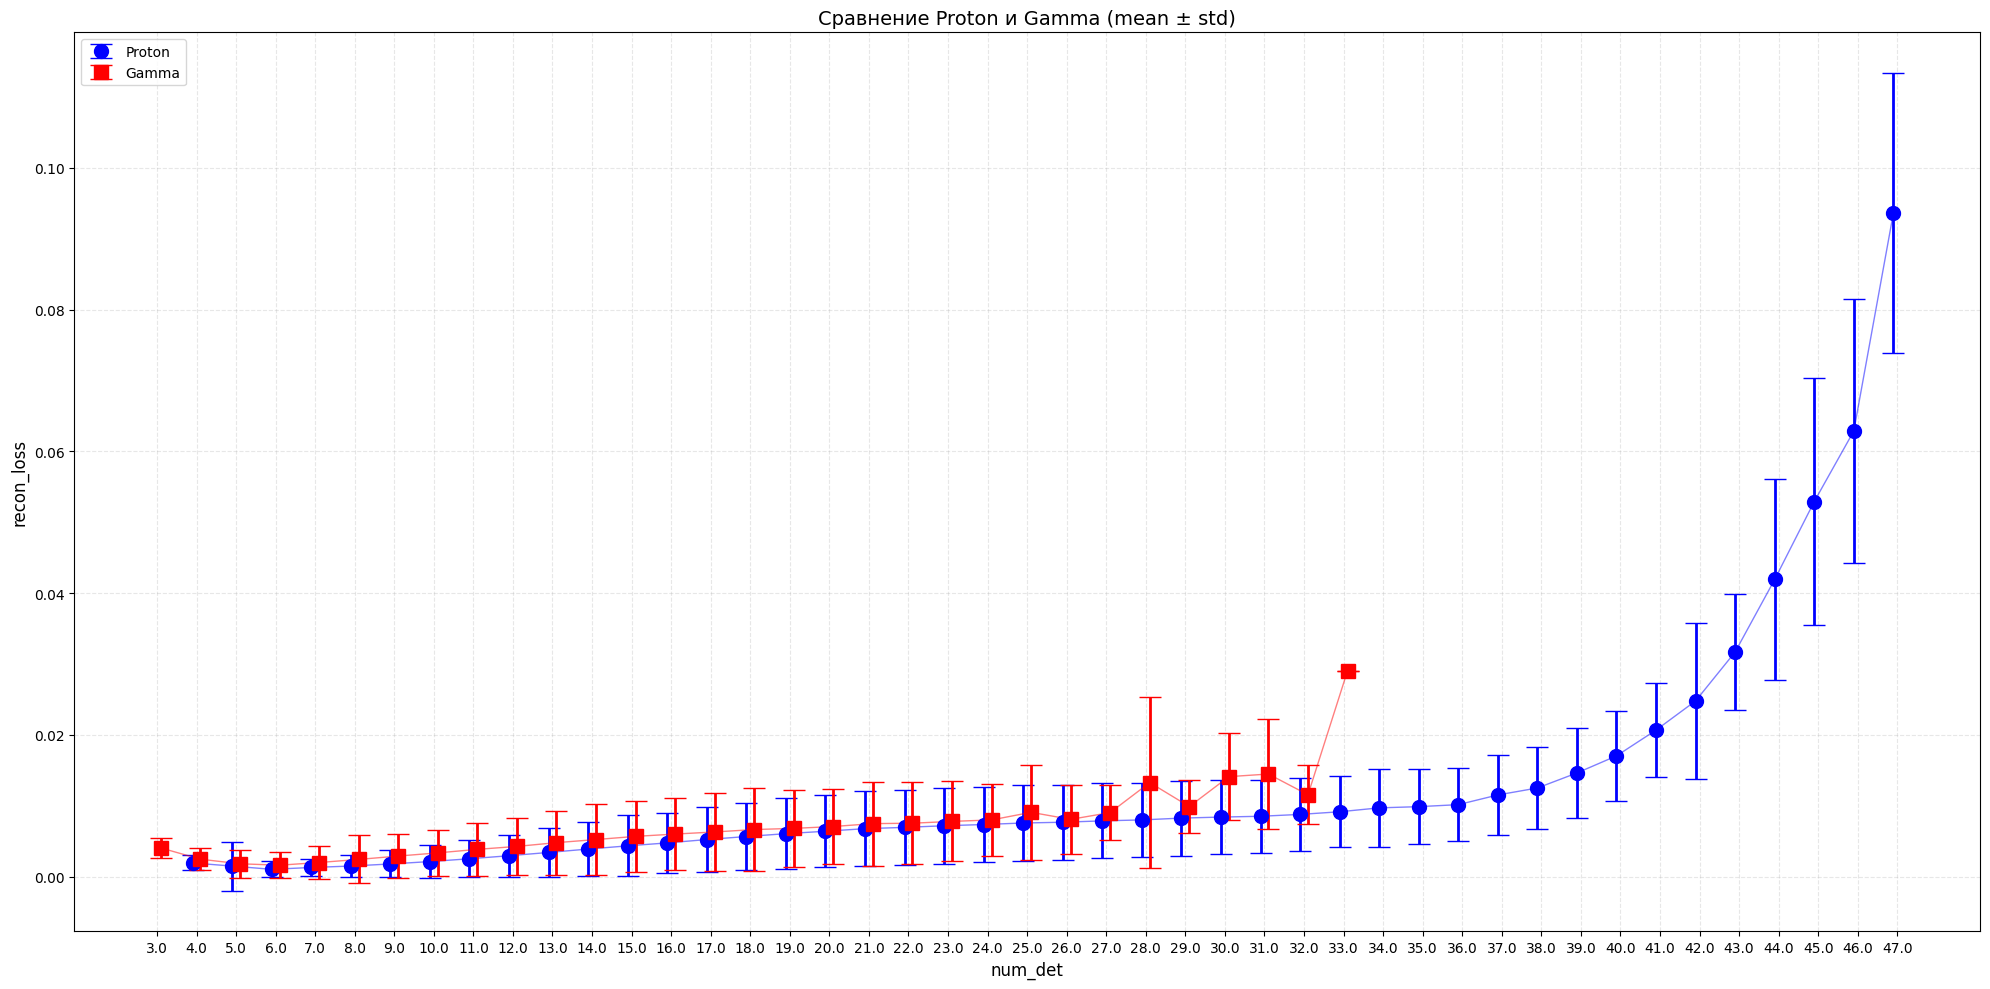

In [8]:
num_det1 = num_det_pr
recon_loss1 = recon_loss_pr
num_det2 = num_det_ph
recon_loss2 = recon_loss_ph

# Создаем DataFrame
df1 = pd.DataFrame({'num_det': num_det1, 'recon_loss': recon_loss1})
df2 = pd.DataFrame({'num_det': num_det2, 'recon_loss': recon_loss2})

# 1. Кресты ошибок на одном графике
fig = plot_errorbar_comparison(
    data1=df1,
    data2=df2,
    labels1="Proton",
    labels2="Gamma",
    title="Сравнение Proton и Gamma (mean ± std)",
    error_type='std',  # Можно поменять на 'sem', 'ci95', 'range'
    style='combined',
    figsize=(20, 10),
    markersize=10,
    capsize=8
)

pr 14.394661648537562 6.337312265108532
gamma 10.218860707043266 3.540141925026593


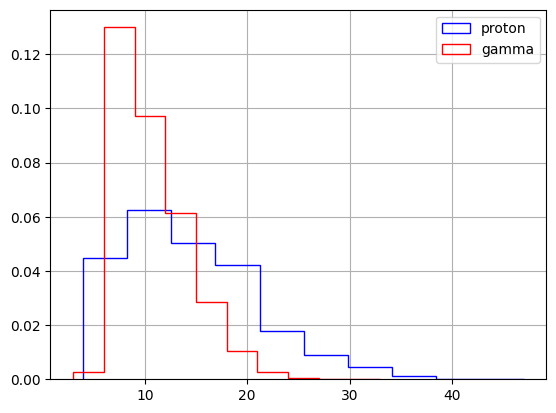

In [9]:
print('pr', num_det_pr.mean(),num_det_pr.std())
print('gamma', num_det_ph.mean(),num_det_ph.std())
plt.hist(num_det_pr, color='b', density=True, histtype='step', label ='proton')
plt.hist(num_det_ph, color='r', density=True, histtype='step', label ='gamma')
plt.grid()
plt.legend()

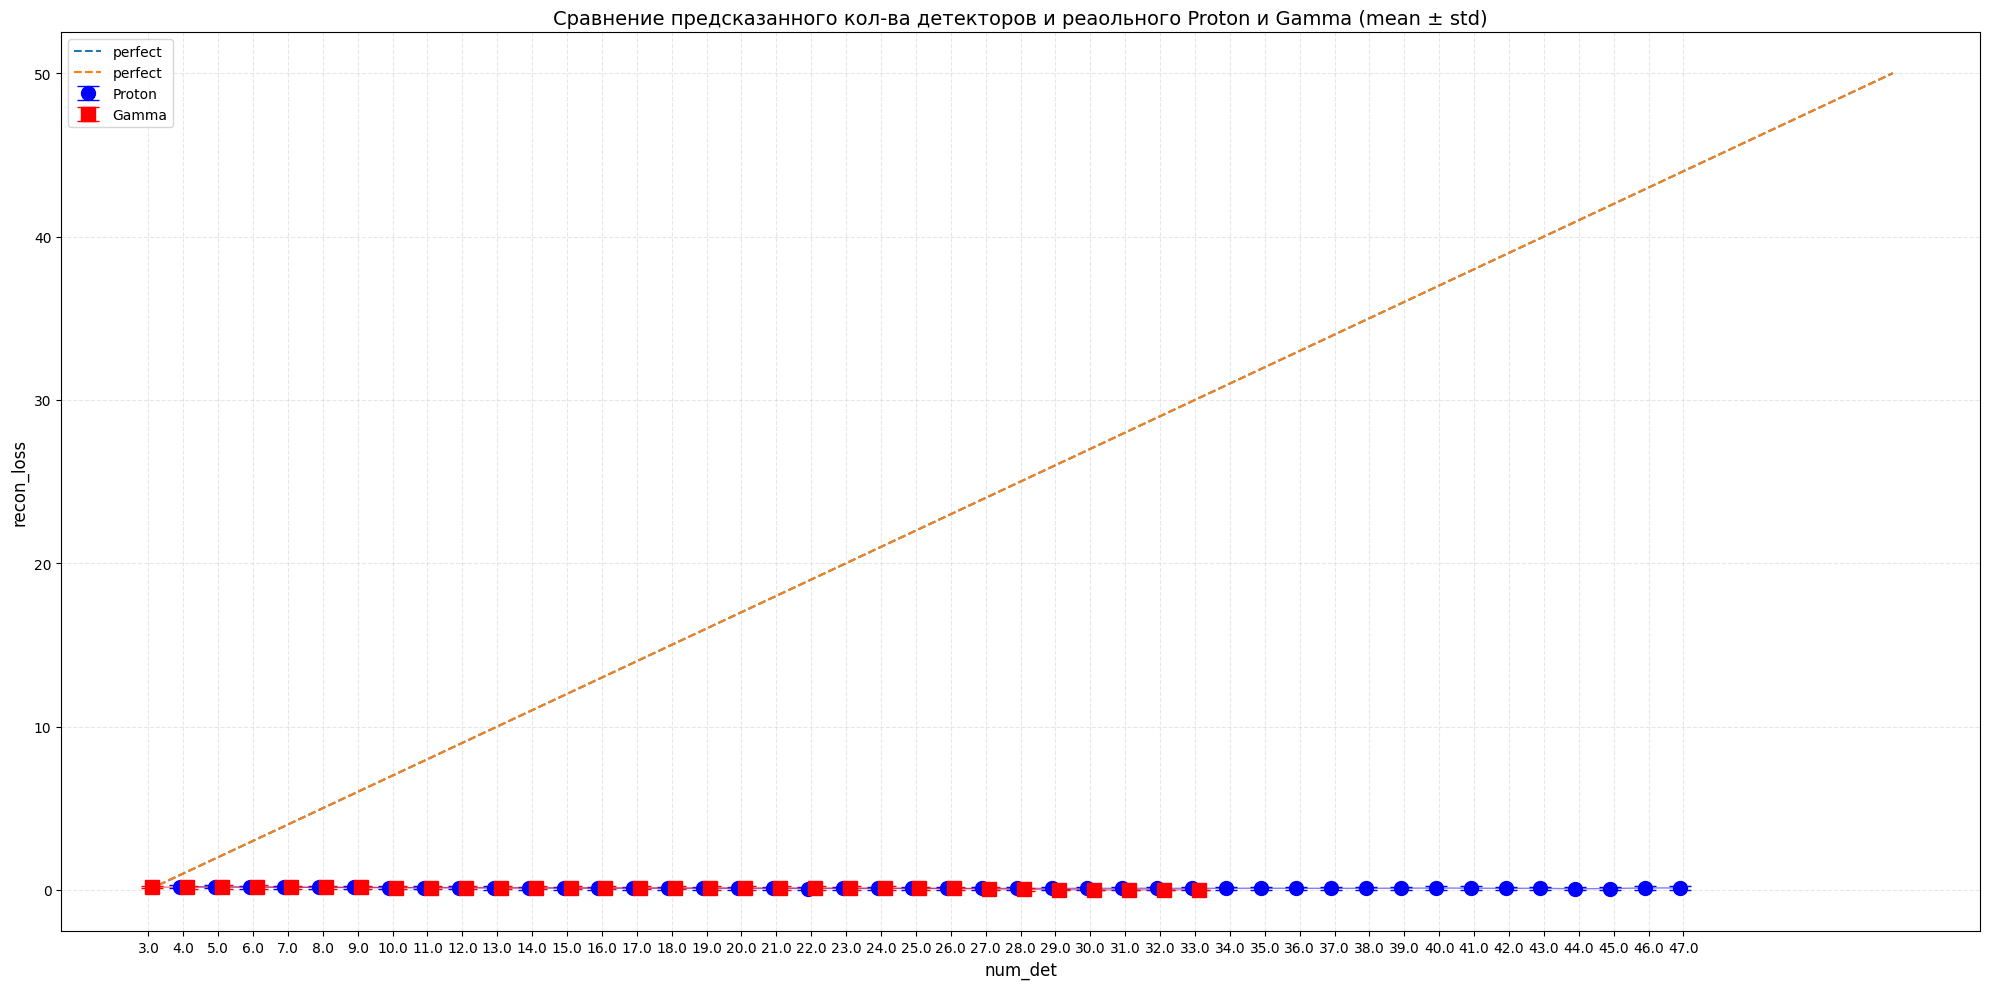

In [10]:

df1 = pd.DataFrame({'num_det': num_det1, 'recon_loss': num_det_pred_pr})
df2 = pd.DataFrame({'num_det': num_det2, 'recon_loss': num_det_pred_ph})

# 1. Кресты ошибок на одном графике
fig = plot_errorbar_comparison(
    data1=df1,
    data2=df2,
    labels1="Proton",
    labels2="Gamma",
    title="Сравнение предсказанного кол-ва детекторов и реаольного Proton и Gamma (mean ± std)",
    error_type='std',  # Можно поменять на 'sem', 'ci95', 'range'
    style='combined',
    figsize=(20, 10),
    markersize=10,
    capsize=8,
    draw_11=True
)

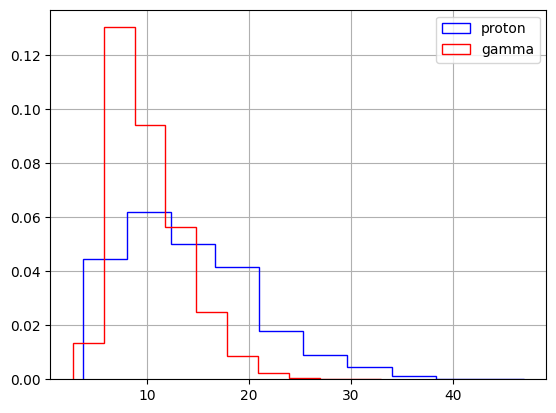

In [11]:
plt.hist(num_det1 -num_det_pred_pr, color='b', density=True, histtype='step', label ='proton')
plt.hist(num_det2 -num_det_pred_ph, color='r', density=True, histtype='step', label ='gamma')
plt.grid()
plt.legend()

Text(0.5, 1.0, 'Разница предсказаного кол-ва детекторов и релаьного')

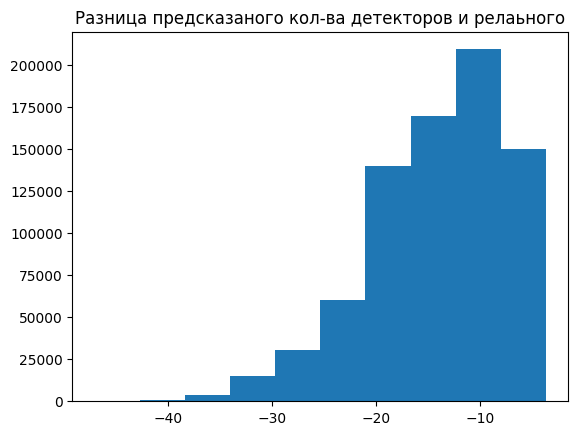

In [12]:
plt.hist( num_det_pred_pr-num_det1)
plt.title("Разница предсказаного кол-ва детекторов и релаьного")

Embegig analys

Text(0.5, 1.0, 'Распределение латеного пространства proton')

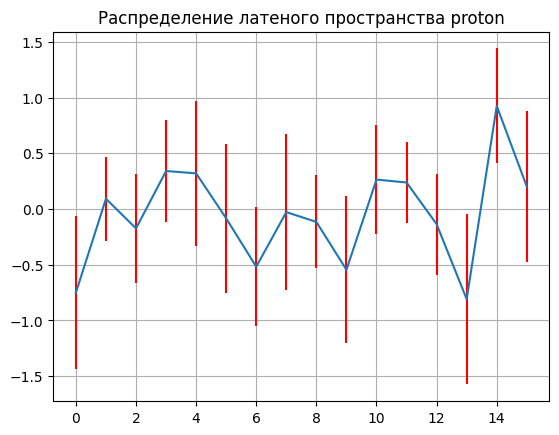

In [13]:

std = embeding_pr.std(axis=0)
mean = embeding_pr.mean(axis=0)
plt.errorbar(np.arange(std.shape[0]), mean, std, ecolor = 'r')
plt.grid()
plt.title('Распределение латеного пространства proton' )

Text(0.5, 1.0, 'Распределение log-var пространства proton')

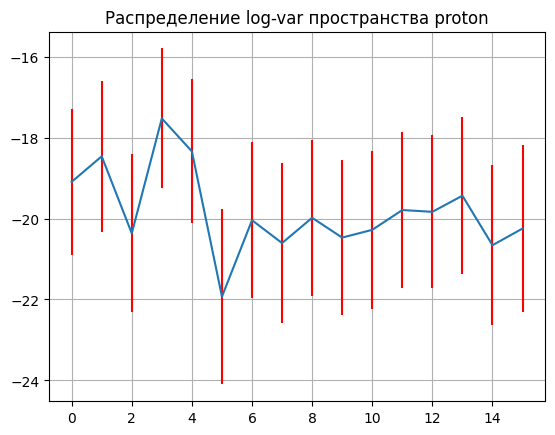

In [14]:
std = preds_log_var_pr.std(axis=0)
mean = preds_log_var_pr.mean(axis=0)
plt.errorbar(np.arange(std.shape[0]), mean, std, ecolor = 'r')
plt.grid()
plt.title('Распределение log-var пространства proton')